# 📊 Exploratory Data Analysis on Retail Sales Data

## Oasis Infobyte Data Analytics Internship (OIBSIP)

**Author:** Deborah K.

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## Project Overview

Retail businesses generate thousands of sales transactions every day. Understanding customer purchasing behaviour, product performance, and sales trends is essential for making informed business decisions.

This project performs an end-to-end Exploratory Data Analysis (EDA) on a retail sales dataset to uncover hidden patterns, identify customer trends, and provide actionable business recommendations.

The analysis follows a structured business-oriented workflow, transforming raw transactional data into meaningful insights that support decision-making.

# Table of Contents

1. Business Problem
2. Project Objectives
3. Dataset Description
4. Analysis Workflow
5. Data Loading
6. Data Inspection
7. Data Cleaning
8. Feature Engineering
9. Descriptive Statistics
10. Exploratory Data Analysis
11. Business Recommendations
12. Conclusion

# Business Problem

Retail companies rely on sales data to understand customer purchasing behaviour, product performance, and revenue trends.

The management team wants to answer several important business questions:

- Which months generate the highest sales?
- Which quarters perform best?
- Which customer age groups contribute the most revenue?
- Is there any difference in purchasing behaviour between male and female customers?
- Which product categories perform best?
- Are there relationships between customer demographics and spending behaviour?

The objective of this project is to transform historical retail transaction data into actionable business insights that support strategic decision-making.

# Project Objectives

This project aims to:

- Understand the structure and quality of the retail sales dataset.
- Clean and prepare the dataset for analysis.
- Perform descriptive statistical analysis.
- Analyse monthly and quarterly sales trends.
- Explore customer demographics.
- Evaluate product category performance.
- Identify relationships between numerical variables.
- Present findings through effective visualisations.
- Generate actionable business recommendations based on data.

# Dataset Description

The dataset contains retail sales transactions collected over one year.

Each row represents a single customer purchase and contains the following information:

- Transaction ID
- Date
- Customer ID
- Gender
- Age
- Product Category
- Quantity
- Price per Unit
- Total Amount

These features allow analysis of customer demographics, purchasing behaviour, sales performance, and revenue trends.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

# Plot styling
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/retail_sales_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Dataset Shape

rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 1000
Number of Columns : 9


In [5]:
# Display First Five Rows

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# Dataset Overview

This section examines the structure, data types, and completeness of the dataset before performing any analysis. Understanding the dataset helps identify potential issues such as missing values or incorrect data types that may affect the quality of the analysis.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


# Data Type Conversion

The Date column is currently stored as text. To enable time-based analysis such as monthly and quarterly sales trends, it will be converted into the datetime format.

In [7]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(df["Date"])

# Verify the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


# Missing Value Check

Missing values can affect the accuracy of analysis and visualizations. This section verifies whether any columns contain null values.

In [8]:
# Check for missing values

df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

# Duplicate Records

Duplicate records can distort statistics and trends. This section checks whether duplicate transactions exist in the dataset.

In [9]:
# Check duplicate rows

duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


# Descriptive Statistics

This section summarizes the numerical variables using measures such as mean, median, mode, and standard deviation.

In [10]:
# Summary statistics

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Transaction ID,1000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.819436
Date,1000,2023-07-03 00:25:55.200000,2023-01-01 00:00:00,2023-04-08 00:00:00,2023-06-29 12:00:00,2023-10-04 00:00:00,2024-01-01 00:00:00,NaN
Age,1000.0,41.392,18.0,29.0,42.0,53.0,64.0,13.68143
Quantity,1000.0,2.514,1.0,1.0,3.0,4.0,4.0,1.132734
Price per Unit,1000.0,179.89,25.0,30.0,50.0,300.0,500.0,189.681356
Total Amount,1000.0,456.0,25.0,60.0,135.0,900.0,2000.0,559.997632


In [11]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [12]:
df.mode(numeric_only=True).iloc[0]

Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

In [13]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

# Feature Engineering

Additional time-based features are created from the Date column to support monthly and quarterly sales analysis.

In [14]:
df["Month"] = df["Date"].dt.month_name()
df["Month_Num"] = df["Date"].dt.month
df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Num,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,11,Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2,Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,5,Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,5,Q2


In [31]:
from pathlib import Path

IMAGE_DIR = Path("../images")
IMAGE_DIR.mkdir(exist_ok=True)

# Monthly Sales Trend

This visualization shows how total sales vary across different months of the year.

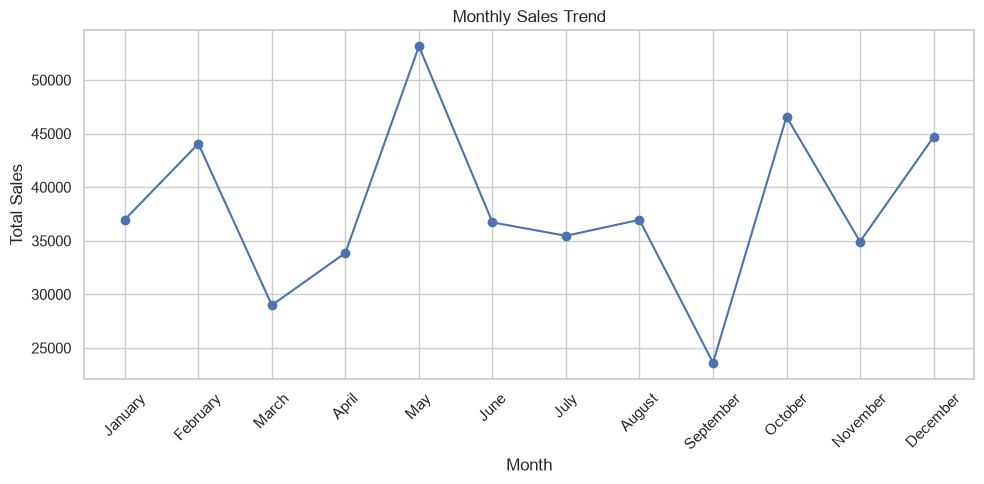

In [15]:
monthly_sales = (
    df.groupby(["Month_Num", "Month"])["Total Amount"]
      .sum()
      .reset_index()
      .sort_values("Month_Num")
)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales["Month"], monthly_sales["Total Amount"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

# Quarterly Sales Trend

Quarterly sales provide a broader view of business performance throughout the year.

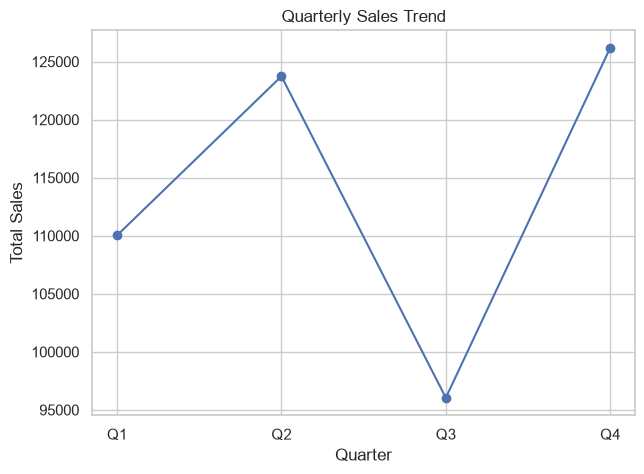

In [16]:
quarterly_sales = (
    df.groupby("Quarter")["Total Amount"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(7,5))
plt.plot(
    quarterly_sales["Quarter"],
    quarterly_sales["Total Amount"],
    marker="o"
)
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Customer Demographics Analysis

Understanding customer demographics helps identify the primary customer segments and supports targeted marketing strategies.

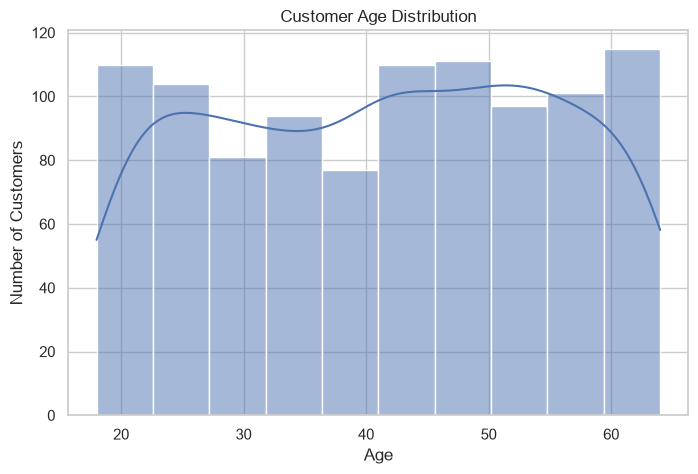

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

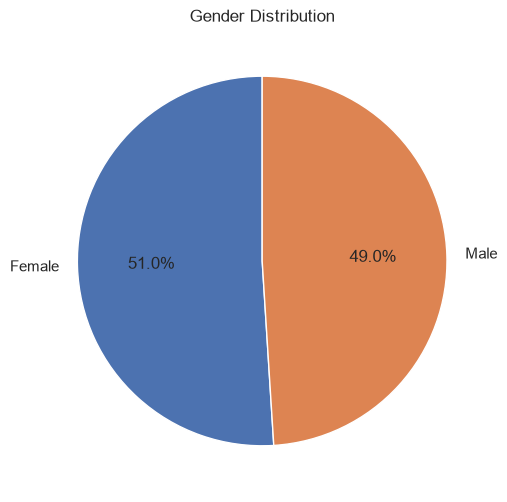

In [18]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

# Product Category Analysis

The dataset contains product categories rather than individual product names. Therefore, the analysis focuses on category-level sales and revenue.

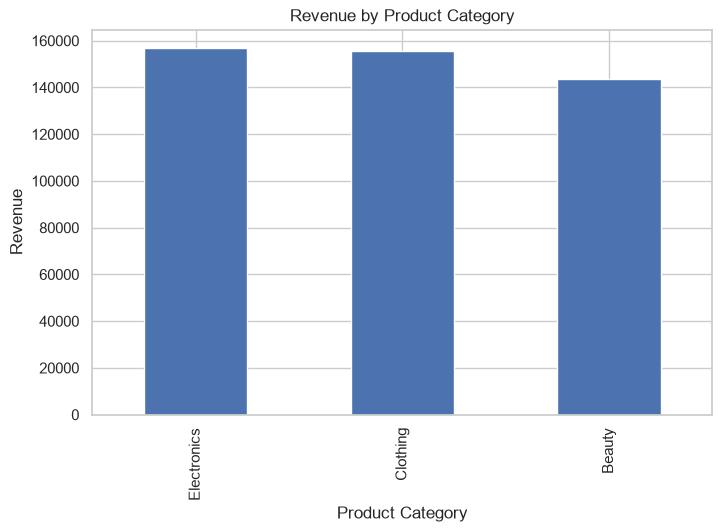

In [19]:
category_sales = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

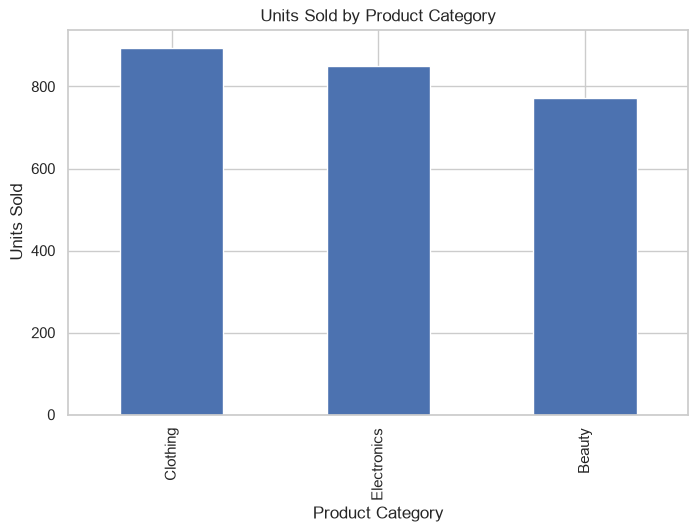

In [20]:
quantity = (
    df.groupby("Product Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

quantity.plot(kind="bar")

plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")

plt.show()

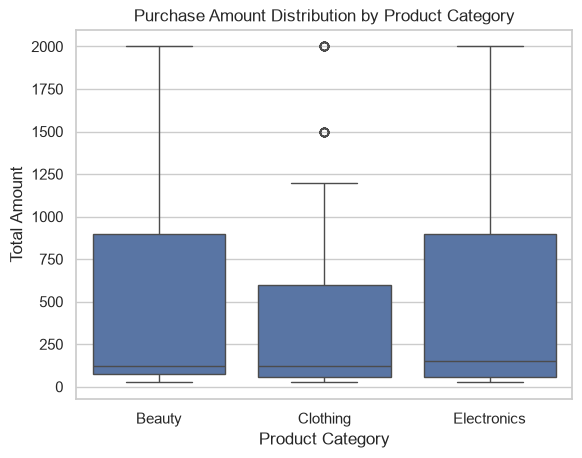

In [28]:
sns.boxplot(
    x="Product Category",
    y="Total Amount",
    data=df
)

plt.title("Purchase Amount Distribution by Product Category")
plt.show()

# Correlation Analysis

Correlation analysis helps identify relationships between numerical variables.

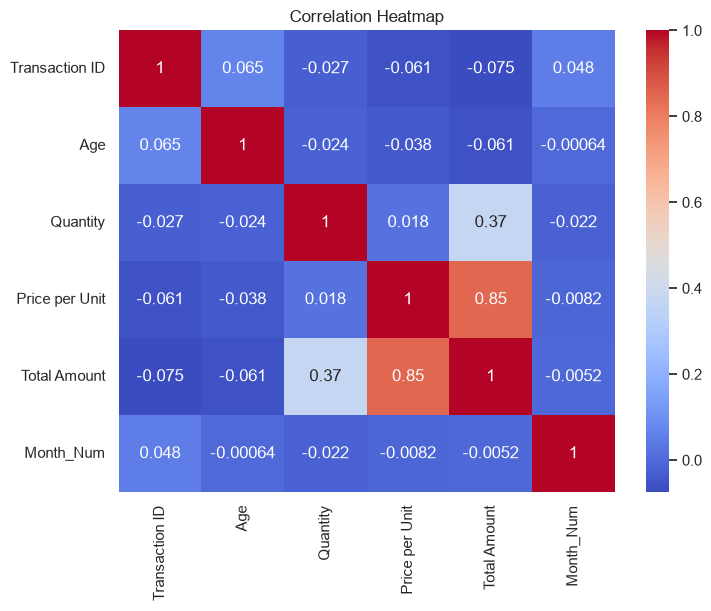

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Average Spending by Age

This visualization explores how spending changes across different customer ages.

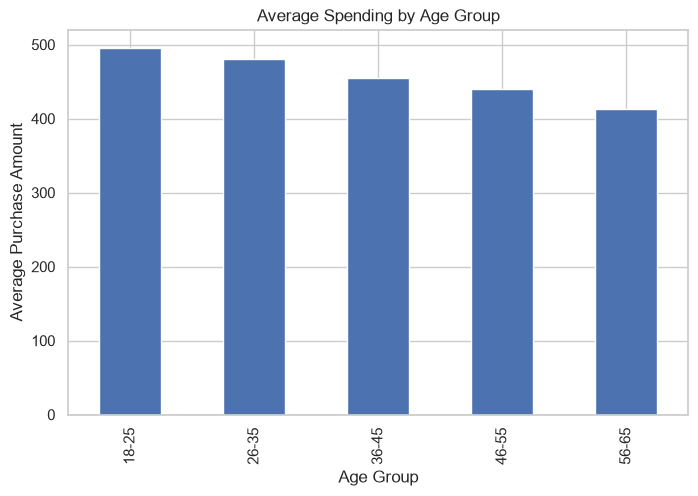

In [26]:
# Create age groups

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,55,65],
    labels=["18-25","26-35","36-45","46-55","56-65"]
)

age_group_spending = (
    df.groupby("Age Group")["Total Amount"]
      .mean()
)

plt.figure(figsize=(8,5))

age_group_spending.plot(kind="bar")

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount")

plt.show()

# Revenue by Gender

While the gender distribution shows the proportion of customers, revenue by gender reveals which customer segment contributes more to total sales.

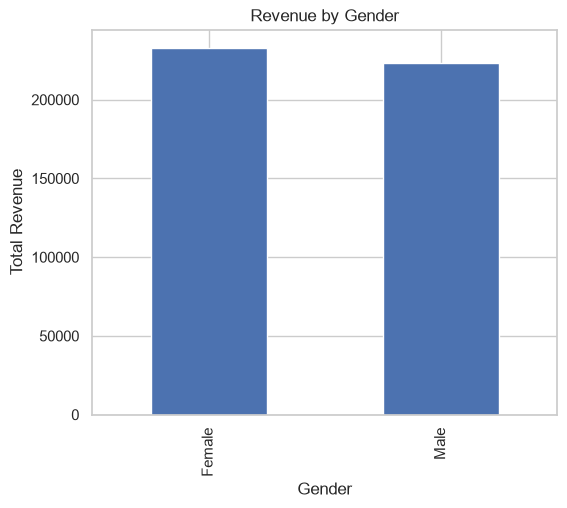

In [23]:
gender_revenue = (
    df.groupby("Gender")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,5))

gender_revenue.plot(kind="bar")

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")

plt.show()

# Average Order Value by Product Category

Average order value compares the typical spending per transaction across product categories.

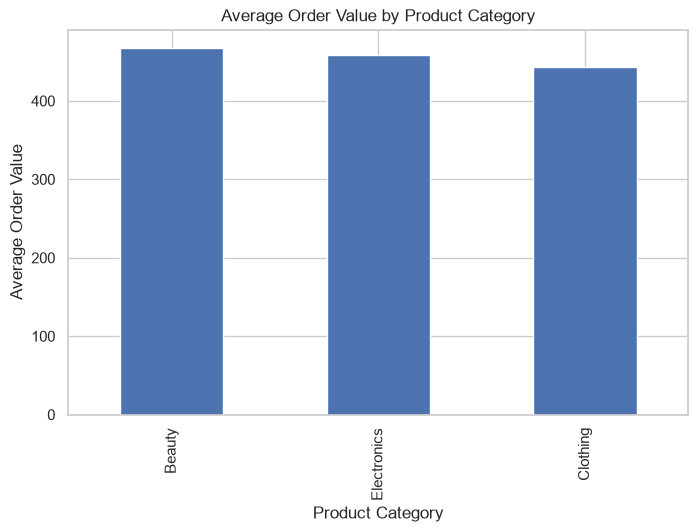

In [24]:
avg_order = (
    df.groupby("Product Category")["Total Amount"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

avg_order.plot(kind="bar")

plt.title("Average Order Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Order Value")

plt.show()

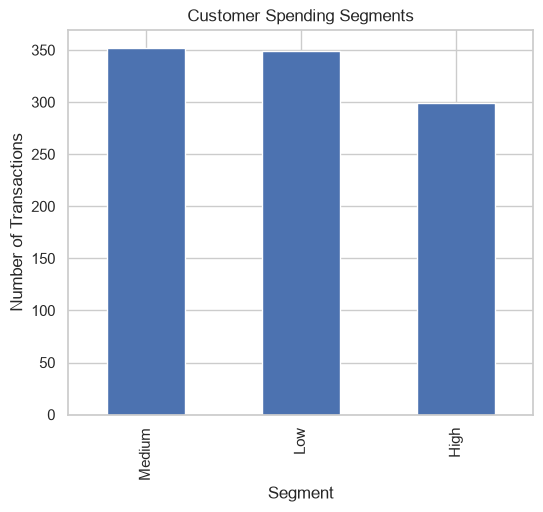

In [25]:
df["Spending Level"] = pd.qcut(
    df["Total Amount"],
    q=3,
    labels=["Low", "Medium", "High"]
)

spending = df["Spending Level"].value_counts()

plt.figure(figsize=(6,5))

spending.plot(kind="bar")

plt.title("Customer Spending Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Transactions")

plt.show()

# Executive Summary

This project presents an exploratory data analysis (EDA) of a retail sales dataset containing 1,000 customer transactions. The objective was to identify sales patterns, understand customer demographics, evaluate product category performance, and uncover relationships between key business variables using Python, Pandas, Matplotlib, and Seaborn.

The analysis revealed that sales fluctuate throughout the year, with May recording the highest monthly revenue and Q4 outperforming the other quarters. Electronics and Clothing generated the highest overall revenue, while Beauty products achieved the highest average order value despite having lower sales volume. Customer purchases were almost evenly distributed between male and female customers, and product price showed the strongest influence on transaction value.

The insights from this analysis can support better inventory planning, pricing decisions, product strategy, and marketing efforts.

### Observation

Monthly sales were not consistent throughout the year. Revenue peaked in **May**, declined to its lowest level in **September**, and recovered strongly in **October** and **December**. This pattern suggests seasonal fluctuations in customer purchasing behaviour that should be considered when planning inventory and promotional activities.

### Observation

Quarterly analysis shows that **Q4 generated the highest total revenue**, while **Q3 recorded the lowest sales performance**. The strong performance during the final quarter suggests increased customer spending towards the end of the year, whereas Q3 may require additional marketing or promotional efforts.

### Observation

Customer ages are spread across a wide range, indicating that the business attracts customers from multiple age groups rather than relying on a single dominant demographic. This suggests broad market appeal across different age segments.

### Observation

The customer base is almost evenly split between female (51%) and male (49%) customers. This balanced distribution suggests that the business successfully appeals to both genders without significant dependence on a single customer segment.

### Observation

Electronics and Clothing generated the highest total revenue, while Beauty products produced comparatively lower overall revenue. This indicates that Electronics and Clothing are currently the strongest contributors to business sales.

### Observation

Clothing recorded the highest number of units sold, followed closely by Electronics, while Beauty products recorded the fewest units sold. This suggests stronger customer demand for Clothing products in terms of purchase volume.

### Observation

Price per Unit shows a strong positive correlation (**0.85**) with Total Amount, indicating that transaction value is primarily influenced by product price. Quantity has a moderate positive relationship (**0.37**) with Total Amount, while customer age shows almost no relationship with spending.

### Observation

Female customers generated slightly higher total revenue than male customers. However, the difference is relatively small, indicating that both customer groups contribute almost equally to the business's overall sales.

### Observation

Although Beauty products generated lower total revenue and fewer unit sales, they recorded the highest average order value. This suggests that customers purchasing Beauty products tend to spend more per transaction than customers purchasing other product categories.

# Business Recommendations

Based on the findings from this analysis, the following recommendations are proposed:

### 1. Prepare for Seasonal Demand

Sales peaked in May and during the fourth quarter, while September recorded the lowest sales. The business should increase inventory levels and marketing activities before high-demand periods while introducing targeted promotions during slower months to improve sales consistency.

### 2. Strengthen Electronics and Clothing Performance

Electronics and Clothing generated the highest overall revenue and should remain priority product categories. Maintaining adequate inventory and promoting these categories can help sustain strong sales performance.

### 3. Expand Premium Beauty Products

Although Beauty products generated lower overall revenue, they achieved the highest average order value. Introducing additional premium beauty products or targeted promotions may increase overall revenue from this category.

### 4. Continue Marketing to Both Genders

Since male and female customers contribute almost equally to total revenue, marketing campaigns should continue targeting both groups while exploring personalized promotions based on customer purchasing behaviour rather than gender alone.

### 5. Review Pricing Strategies

The strong correlation between Price per Unit and Total Amount indicates that pricing significantly influences revenue. Regular pricing reviews and value-based pricing strategies may help maximize profitability while maintaining customer satisfaction.

### 6. Encourage Higher-Value Purchases

Most transactions fall within the Low and Medium spending segments. Product bundles, loyalty rewards, and cross-selling strategies could encourage customers to move into the High spending segment, increasing average transaction value.

# Conclusion

This exploratory data analysis successfully identified key patterns in retail sales performance, customer demographics, and product category performance. The findings show that sales fluctuate throughout the year, with stronger performance in May and the fourth quarter, while Electronics and Clothing contribute the highest overall revenue. Although Beauty products generate fewer sales, they achieve the highest average order value, highlighting opportunities for premium product growth.

Overall, this analysis demonstrates how exploratory data analysis can transform raw retail transaction data into actionable business insights that support inventory planning, pricing strategies, marketing decisions, and long-term business growth.